# Telecom CDR Fraud — Détection de fraude + Adaptation au contexte marocain

## Objectif du notebook

Ce notebook a pour objectif d’analyser un dataset **Telecom CDR (Call Detail Records)** afin de détecter des comportements suspects ou frauduleux dans l'utilisation des services téléphoniques.

L'analyse inclut :

- Le **prétraitement et nettoyage des données**
- L’**adaptation du dataset au contexte marocain** (opérateurs, coûts estimés en MAD, roaming, départements d’entreprise)
- L’entraînement et la comparaison de **trois modèles de Machine Learning**
- L’évaluation des performances afin de **sélectionner le meilleur modèle**
- La génération d’un **score de risque de fraude**
- La création d’**alertes et recommandations** pour une plateforme intelligente de gestion de flotte téléphonique.

## Modèles testés

Les modèles utilisés pour la comparaison sont :

- **Logistic Regression**
- **Random Forest**
- **XGBoost**

Les performances sont évaluées à l’aide de métriques telles que :

- Accuracy
- ROC AUC
- Classification Report

## Application dans le projet

Les résultats permettent de :

- détecter les appels ou comportements anormaux,
- identifier les lignes à risque,
- générer des alertes automatiques,
- aider les gestionnaires de flotte à **optimiser les coûts et surveiller l'utilisation des lignes téléphoniques**.

In [1]:
# ============================================================
# CELLULE 2 — IMPORT DES LIBRAIRIES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

In [2]:
# ============================================================
# CELLULE 3 — CHARGEMENT AUTOMATIQUE DU DATASET
# ============================================================

base_path = "/kaggle/input"
csv_path = None

for root, dirs, files in os.walk(base_path):
    for f in files:
        if f.lower().endswith(".csv"):
            csv_path = os.path.join(root, f)
            print("CSV trouvé :", csv_path)

if csv_path is None:
    raise FileNotFoundError("Aucun fichier CSV trouvé dans /kaggle/input")

df = pd.read_csv(csv_path)
df.head()

CSV trouvé : /kaggle/input/datasets/mehmedumer0028/telecom-cdr-fraud-dataset/realtime_cdr_fraud_dataset.csv


,caller_id,receiver_id,start_time,duration_sec,call_type,sim_id,device_id,location_origin,country_origin,location_dest,country_dest,is_night_call,transaction_status,fraud_type
0,3211281536,3037163426,2025-05-31 16:09:56,293,local,SIM007367,DEV02445,Kampala,UG,Johannesburg,ZA,0,Genuine,none
1,6322161221,7891405286,2025-05-31 16:09:56,213,international,SIM013788,DEV00050,Cairo,EG,Lagos,NG,0,Genuine,none
2,9817588945,2131701684,2025-05-31 16:09:56,191,international,SIM010409,DEV08742,Lagos,NG,Lagos,NG,0,Genuine,none
3,7187231493,7356618128,2025-05-31 16:09:56,14,international,SIM001431,DEV02109,Nairobi,KE,Addis Ababa,ET,0,Fraudulent,sim_box_fraud
4,3892030047,8530188712,2025-05-31 16:09:56,166,international,SIM015017,DEV07134,Cairo,EG,Addis Ababa,ET,0,Genuine,none


In [3]:
# ============================================================
# CELLULE 4 — EXPLORATION DES DONNEES
# ============================================================

print("Shape :", df.shape)
print("\nColonnes :\n", df.columns.tolist())
print("\nTypes :\n")
print(df.dtypes)

print("\nValeurs manquantes :\n")
print(df.isna().sum().sort_values(ascending=False).head(20))

Shape : (24543, 14)

Colonnes :
 ['caller_id', 'receiver_id', 'start_time', 'duration_sec', 'call_type', 'sim_id', 'device_id', 'location_origin', 'country_origin', 'location_dest', 'country_dest', 'is_night_call', 'transaction_status', 'fraud_type']

Types :

caller_id              int64
receiver_id            int64
start_time            object
duration_sec           int64
call_type             object
sim_id                object
device_id             object
location_origin       object
country_origin        object
location_dest         object
country_dest          object
is_night_call          int64
transaction_status    object
fraud_type            object
dtype: object

Valeurs manquantes :

caller_id             0
receiver_id           0
start_time            0
duration_sec          0
call_type             0
sim_id                0
device_id             0
location_origin       0
country_origin        0
location_dest         0
country_dest          0
is_night_call         0
transact

In [4]:
# ============================================================
# CELLULE 5 — DETECTION DE LA VARIABLE CIBLE
# ============================================================

possible_targets = ["fraud", "is_fraud", "label", "class", "target", "fraud_flag"]

target_col = None
for col in df.columns:
    if col.lower() in possible_targets:
        target_col = col
        break

if target_col is not None:
    print("Colonne cible détectée :", target_col)
else:
    print("⚠ Aucune colonne cible réelle détectée.")
    print("Une cible simulée sera créée plus tard après l'adaptation métier.")

⚠ Aucune colonne cible réelle détectée.
Une cible simulée sera créée plus tard après l'adaptation métier.


In [5]:
# ============================================================
# CELLULE 6 — NETTOYAGE INITIAL
# ============================================================

df = df.copy()

# Supprimer colonnes purement identifiantes si elles existent
id_like_cols = [col for col in df.columns if "id" in col.lower() or "number" in col.lower()]
print("Colonnes identifiantes candidates :", id_like_cols)

# On garde la cible si elle existe, sinon on supprime tous les ID-like
cols_to_drop = [col for col in id_like_cols if col != target_col] if target_col else id_like_cols

df.drop(columns=cols_to_drop, inplace=True, errors="ignore")

# Remplissage simple des valeurs manquantes
for col in df.columns:
    if target_col is not None and col == target_col:
        continue
    if df[col].dtype == "object":
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].fillna(df[col].median())

print("Nettoyage terminé.")
print(df.head())

Colonnes identifiantes candidates : ['caller_id', 'receiver_id', 'sim_id', 'device_id']
Nettoyage terminé.
            start_time  duration_sec      call_type location_origin  \
0  2025-05-31 16:09:56           293          local         Kampala   
1  2025-05-31 16:09:56           213  international           Cairo   
2  2025-05-31 16:09:56           191  international           Lagos   
3  2025-05-31 16:09:56            14  international         Nairobi   
4  2025-05-31 16:09:56           166  international           Cairo   

  country_origin location_dest country_dest  is_night_call transaction_status  \
0             UG  Johannesburg           ZA              0            Genuine   
1             EG         Lagos           NG              0            Genuine   
2             NG         Lagos           NG              0            Genuine   
3             KE   Addis Ababa           ET              0         Fraudulent   
4             EG   Addis Ababa           ET              0   

In [6]:
# ============================================================
# CELLULE 7 — ENCODAGE DE LA CIBLE SI ELLE EXISTE
# ============================================================

if target_col is not None:
    print("Valeurs uniques de la cible avant traitement :", df[target_col].unique()[:20])

    if df[target_col].dtype == "object":
        mapping = {
            "yes": 1, "no": 0,
            "fraud": 1, "non-fraud": 0,
            "true": 1, "false": 0,
            "1": 1, "0": 0
        }
        df[target_col] = df[target_col].astype(str).str.lower().map(mapping)

    df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
    df = df.dropna(subset=[target_col])
    df[target_col] = df[target_col].astype(int)

    print("Valeurs uniques de la cible après traitement :", df[target_col].unique())
    print(df[target_col].value_counts())
else:
    print("Aucune cible réelle à encoder pour le moment.")

Aucune cible réelle à encoder pour le moment.


In [7]:
# ============================================================
# CELLULE 8 — ADAPTATION AU CONTEXTE MAROCAIN + VRAIE CIBLE
# ============================================================

np.random.seed(42)

df_ma = df.copy()

# =========================
# ADAPTATION METIER MAROC
# =========================

# Opérateurs marocains simulés
operators = ["Maroc Telecom", "Orange Maroc", "inwi"]
df_ma["operator_maroc"] = np.random.choice(operators, size=len(df_ma), p=[0.45, 0.30, 0.25])

# Départements simulés
departments = ["IT", "Finance", "RH", "Commercial", "Support", "Direction"]
df_ma["department"] = np.random.choice(departments, size=len(df_ma), p=[0.18, 0.15, 0.12, 0.25, 0.20, 0.10])

# Zone d’appel
def assign_call_zone(call_type):
    if str(call_type).lower() == "international":
        return np.random.choice(["International", "Roaming"], p=[0.75, 0.25])
    return "National"

df_ma["call_zone"] = df_ma["call_type"].apply(assign_call_zone)

# Roaming
df_ma["roaming_flag"] = (df_ma["call_zone"] == "Roaming").astype(int)

# =========================
# FEATURES METIER
# =========================

duration_candidates = [c for c in df_ma.columns if "dur" in c.lower() or "sec" in c.lower()]
print("Colonnes candidates durée :", duration_candidates)

duration_col = duration_candidates[0] if len(duration_candidates) > 0 else None

if duration_col:
    df_ma["call_cost_mad"] = (
        pd.to_numeric(df_ma[duration_col], errors="coerce").fillna(0) *
        np.where(df_ma["call_zone"] == "National", 0.35,
                 np.where(df_ma["call_zone"] == "International", 1.2, 2.5))
    ).round(2)
else:
    df_ma["call_cost_mad"] = np.random.uniform(1, 50, len(df_ma)).round(2)

# Flags métier
df_ma["high_cost_flag"] = (df_ma["call_cost_mad"] > df_ma["call_cost_mad"].quantile(0.90)).astype(int)

if duration_col:
    df_ma["long_duration_flag"] = (
        pd.to_numeric(df_ma[duration_col], errors="coerce").fillna(0) >
        pd.to_numeric(df_ma[duration_col], errors="coerce").fillna(0).quantile(0.90)
    ).astype(int)
else:
    df_ma["long_duration_flag"] = 0

df_ma["international_flag"] = (df_ma["call_zone"] == "International").astype(int)

# =========================
# VRAIE CIBLE (IMPORTANT 🔥)
# =========================

print("Valeurs transaction_status :", df_ma["transaction_status"].unique())

mapping_fraud = {
    "Genuine": 0,
    "Fraudulent": 1
}

df_ma["fraud_flag"] = df_ma["transaction_status"].map(mapping_fraud)

# Vérification erreurs
unmapped = df_ma[df_ma["fraud_flag"].isna()]["transaction_status"].unique()
if len(unmapped) > 0:
    print("⚠ Valeurs non mappées :", unmapped)

df_ma = df_ma.dropna(subset=["fraud_flag"])
df_ma["fraud_flag"] = df_ma["fraud_flag"].astype(int)

target_col = "fraud_flag"

# Vérification finale
print("\nDistribution cible :")
print(df_ma[target_col].value_counts())

print("\nProportion (%) :")
print((df_ma[target_col].value_counts(normalize=True) * 100).round(2))

print("\nDataset prêt :", df_ma.shape)

Colonnes candidates durée : ['duration_sec']
Valeurs transaction_status : ['Genuine' 'Fraudulent']

Distribution cible :
fraud_flag
1    12320
0    12223
Name: count, dtype: int64

Proportion (%) :
fraud_flag
1    50.2
0    49.8
Name: proportion, dtype: float64

Dataset prêt : (24543, 19)


In [8]:
# ============================================================
# CELLULE 8 BIS — ANALYSE DES VARIABLES POTENTIELLEMENT EN FUITE
# ============================================================

numeric_cols = df_ma.select_dtypes(include=["int64", "float64"]).columns.tolist()

if target_col in numeric_cols:
    corr_with_target = df_ma[numeric_cols].corr()[target_col].sort_values(ascending=False)
    print("Corrélation avec la cible :")
    print(corr_with_target)
else:
    print(f"La cible {target_col} n'est pas numérique.")

Corrélation avec la cible :
fraud_flag            1.000000
international_flag    0.143216
roaming_flag          0.064849
long_duration_flag   -0.058358
high_cost_flag       -0.058489
call_cost_mad        -0.061042
duration_sec         -0.116345
is_night_call              NaN
Name: fraud_flag, dtype: float64


In [9]:
# ============================================================
# CELLULE 9 BIS — PREPARATION DU DATAFRAME POUR LE ML
# ============================================================

df_model_input = df_ma.copy()

leakage_cols = [
    "transaction_status",
    "fraud_type"
]

df_model_input = df_model_input.drop(columns=leakage_cols, errors="ignore")

print("Colonnes supprimées du dataset ML :", leakage_cols)
print("Colonnes restantes pour le ML :")
print(df_model_input.columns.tolist())

Colonnes supprimées du dataset ML : ['transaction_status', 'fraud_type']
Colonnes restantes pour le ML :
['start_time', 'duration_sec', 'call_type', 'location_origin', 'country_origin', 'location_dest', 'country_dest', 'is_night_call', 'operator_maroc', 'department', 'call_zone', 'roaming_flag', 'call_cost_mad', 'high_cost_flag', 'long_duration_flag', 'international_flag', 'fraud_flag']


In [10]:
# ============================================================
# CELLULE 9 TER — FEATURE ENGINEERING TEMPS
# ============================================================

df_model_input["start_time"] = pd.to_datetime(df_model_input["start_time"], errors="coerce")

df_model_input["call_hour"] = df_model_input["start_time"].dt.hour
df_model_input["call_minute"] = df_model_input["start_time"].dt.minute
df_model_input["call_day"] = df_model_input["start_time"].dt.day
df_model_input["call_weekday"] = df_model_input["start_time"].dt.weekday
df_model_input["is_weekend"] = df_model_input["call_weekday"].isin([5, 6]).astype(int)

df_model_input = df_model_input.drop(columns=["start_time"])

print("✅ Features temporelles ajoutées")
print(df_model_input[["call_hour", "call_minute", "call_day", "call_weekday", "is_weekend"]].head())

✅ Features temporelles ajoutées
   call_hour  call_minute  call_day  call_weekday  is_weekend
0         16            9        31             5           1
1         16            9        31             5           1
2         16            9        31             5           1
3         16            9        31             5           1
4         16            9        31             5           1


In [11]:
# ============================================================
# CELLULE 10 — ENCODAGE DES VARIABLES POUR LE ML
# ============================================================

df_model = pd.get_dummies(df_model_input, drop_first=True)

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print("Shape X :", X.shape)
print("Shape y :", y.shape)

Shape X : (24543, 46)
Shape y : (24543,)


Top features :
duration_sec                   0.286503
call_cost_mad                  0.278247
call_minute                    0.040839
operator_maroc_Orange Maroc    0.034492
operator_maroc_inwi            0.030466
department_Support             0.024213
department_IT                  0.023701
department_Finance             0.022036
department_RH                  0.020011
department_Direction           0.017119
dtype: float64


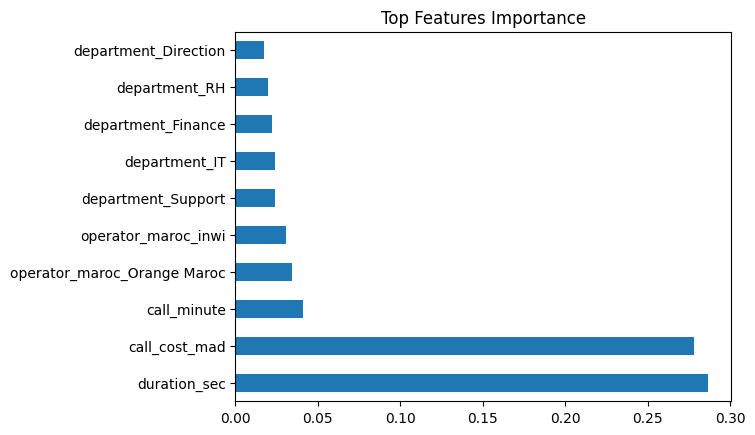

In [12]:
# ============================================================
# CELLULE 10 BIS — FEATURE IMPORTANCE
# ============================================================

# On utilise Random Forest pour importance
rf_temp = RandomForestClassifier(n_estimators=200, random_state=42)
rf_temp.fit(X, y)

importances = pd.Series(rf_temp.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

print("Top features :")
print(top_features)

# Visualisation
top_features.plot(kind="barh", title="Top Features Importance")
plt.show()

In [13]:
# ============================================================
# CELLULE 11 — TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (19634, 46)
Test  : (4909, 46)


In [14]:
# ============================================================
# CELLULE 12 — SCALING POUR LOGISTIC REGRESSION
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_full_scaled = scaler.transform(X)

In [15]:
# ============================================================
# CELLULE 12 BIS — TUNING LOGISTIC REGRESSION
# ============================================================

from sklearn.model_selection import GridSearchCV

param_grid_log = {
    "C": [0.01, 0.1, 1, 5, 10],
    "solver": ["lbfgs"],
    "class_weight": ["balanced"],
    "max_iter": [5000]
}

grid_log = GridSearchCV(
    LogisticRegression(),
    param_grid=param_grid_log,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_log.fit(X_train_scaled, y_train)

print("Meilleurs paramètres Logistic Regression :", grid_log.best_params_)
print("Meilleur ROC AUC CV :", grid_log.best_score_)

best_log_model = grid_log.best_estimator_

Meilleurs paramètres Logistic Regression : {'C': 10, 'class_weight': 'balanced', 'max_iter': 5000, 'solver': 'lbfgs'}
Meilleur ROC AUC CV : 0.6093670480686855


In [16]:
# ============================================================
# CELLULE 13 — MODELE 1 : LOGISTIC REGRESSION
# ============================================================

log_model = best_log_model

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print("✅ Logistic Regression entraîné")

✅ Logistic Regression entraîné


In [17]:
# ============================================================
# CELLULE 14 — MODELE 2 : RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("✅ Random Forest entraîné")

✅ Random Forest entraîné


In [18]:
# ============================================================
# CELLULE 15 BIS — TUNING XGBOOST
# ============================================================

from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    param_grid=param_grid_xgb,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_xgb.best_params_)
print("ROC AUC CV :", grid_xgb.best_score_)

best_xgb_model = grid_xgb.best_estimator_

Meilleurs paramètres : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
ROC AUC CV : 0.6273413090459985


In [19]:
# ============================================================
# CELLULE 15 BIS — TUNING XGBOOST
# ============================================================

from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 6],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid_xgb,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Meilleurs paramètres XGBoost :", grid_xgb.best_params_)
print("Meilleur ROC AUC CV :", grid_xgb.best_score_)

best_xgb_model = grid_xgb.best_estimator_

Meilleurs paramètres XGBoost : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Meilleur ROC AUC CV : 0.6275772489537154


In [20]:
# ============================================================
# CELLULE 15 TER — ENTRAINEMENT XGBOOST FINAL
# ============================================================

xgb_model = best_xgb_model

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("✅ XGBoost entraîné avec les meilleurs paramètres")

✅ XGBoost entraîné avec les meilleurs paramètres


In [21]:
# ============================================================
# CELLULE 16 — COMPARAISON DES MODELES (SAFE VERSION)
# ============================================================

models = []
accuracy_list = []
roc_list = []

# Logistic
models.append("Logistic Regression")
accuracy_list.append(accuracy_score(y_test, log_pred))
roc_list.append(roc_auc_score(y_test, log_proba))

# Random Forest
models.append("Random Forest")
accuracy_list.append(accuracy_score(y_test, rf_pred))
roc_list.append(roc_auc_score(y_test, rf_proba))

# XGBoost (seulement si disponible)
if "xgb_pred" in globals():
    models.append("XGBoost")
    accuracy_list.append(accuracy_score(y_test, xgb_pred))
    roc_list.append(roc_auc_score(y_test, xgb_proba))
else:
    print("⚠ XGBoost non exécuté")

comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy_list,
    "ROC_AUC": roc_list
}).sort_values(by="ROC_AUC", ascending=False).reset_index(drop=True)

comparison

,Model,Accuracy,ROC_AUC
0,XGBoost,0.603789,0.622771
1,Random Forest,0.584437,0.613743
2,Logistic Regression,0.595437,0.600457


In [22]:
# ============================================================
# CELLULE 16 BIS — CROSS VALIDATION (VERSION ROBUSTE)
# ============================================================

from sklearn.model_selection import cross_val_score

# Logistic Regression
cv_log = cross_val_score(
    log_model,
    X_full_scaled,
    y,
    cv=5,
    scoring="roc_auc"
)

# Random Forest
cv_rf = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

# XGBoost (si dispo)
if "xgb_model" in globals():
    cv_xgb = cross_val_score(
        xgb_model,
        X,
        y,
        cv=5,
        scoring="roc_auc"
    )
else:
    cv_xgb = None
    print("⚠ XGBoost non disponible")

print("\n--- CROSS VALIDATION ---")
print("Logistic Regression :", cv_log.mean())
print("Random Forest       :", cv_rf.mean())

if cv_xgb is not None:
    print("XGBoost             :", cv_xgb.mean())


--- CROSS VALIDATION ---
Logistic Regression : 0.6084515195052738
Random Forest       : 0.6119769841637499
XGBoost             : 0.6296596001855799


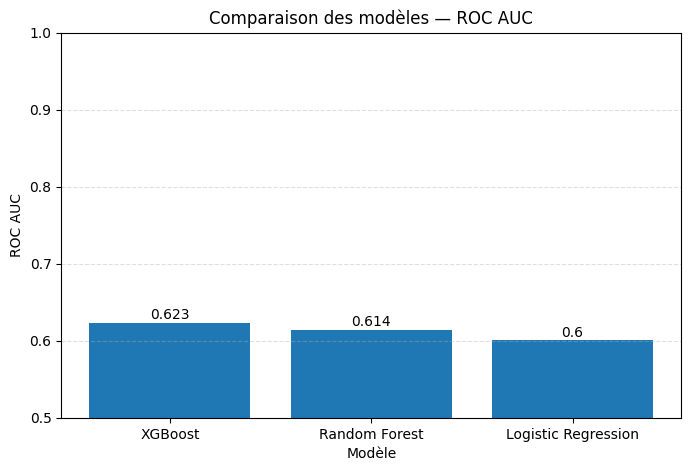

In [23]:
# ============================================================
# CELLULE 17 — VISUALISATION DE LA COMPARAISON
# ============================================================

plt.figure(figsize=(8,5))
bars = plt.bar(comparison["Model"], comparison["ROC_AUC"])

plt.title("Comparaison des modèles — ROC AUC")
plt.xlabel("Modèle")
plt.ylabel("ROC AUC")
plt.ylim(0.5, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 3), ha="center")

plt.show()

In [24]:
# ============================================================
# CELLULE 18 — MEILLEUR MODELE
# ============================================================

best_model_name = comparison.loc[0, "Model"]
best_auc = comparison.loc[0, "ROC_AUC"]

print("✅ Meilleur modèle :", best_model_name)
print("✅ Meilleur ROC AUC :", round(best_auc, 4))

✅ Meilleur modèle : XGBoost
✅ Meilleur ROC AUC : 0.6228


In [25]:
# ============================================================
# CELLULE 19 — RAPPORT DETAILLE DU MEILLEUR MODELE
# ============================================================

if best_model_name == "Logistic Regression":
    best_pred = log_pred
    best_proba_test = log_proba
elif best_model_name == "Random Forest":
    best_pred = rf_pred
    best_proba_test = rf_proba
else:
    best_pred = xgb_pred
    best_proba_test = xgb_proba

print(classification_report(y_test, best_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.57      0.84      0.68      2445
           1       0.70      0.37      0.48      2464

    accuracy                           0.60      4909
   macro avg       0.64      0.60      0.58      4909
weighted avg       0.64      0.60      0.58      4909

Confusion Matrix :
 [[2063  382]
 [1563  901]]


SHAP prêt


/tmp/ipykernel_17/2173436194.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


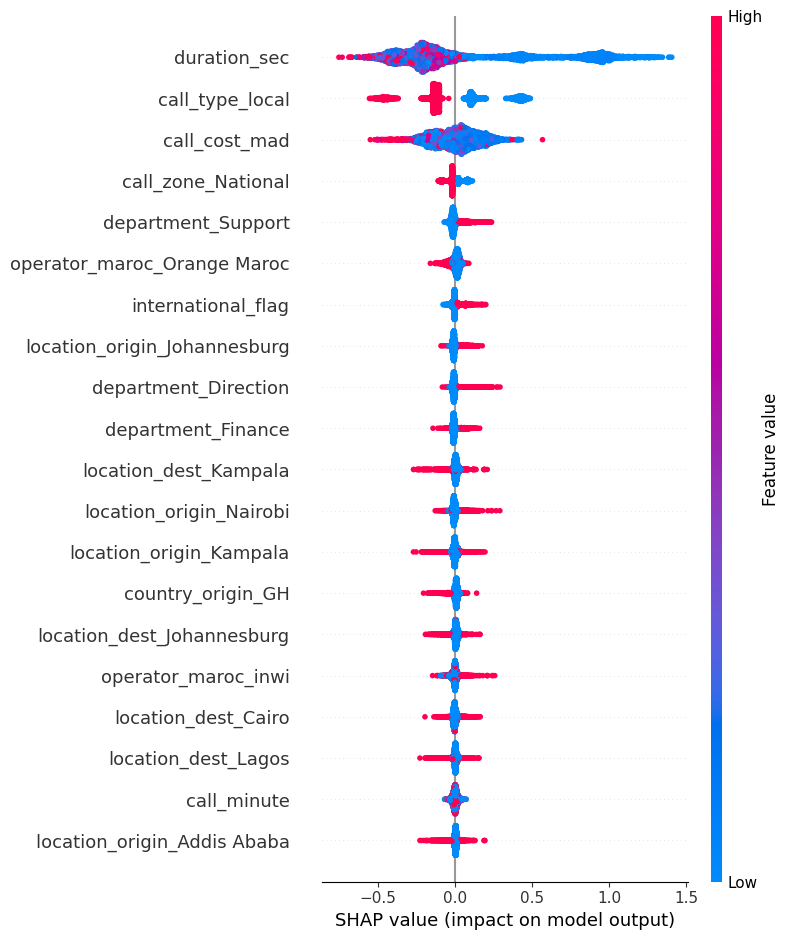

In [26]:
# ============================================================
# CELLULE 19 BIS — SHAP EXPLAINABILITY
# ============================================================

import shap

# On prend le meilleur modèle
if best_model_name == "Random Forest":
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_test)
elif best_model_name == "XGBoost":
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test)
else:
    # Logistic Regression
    explainer = shap.LinearExplainer(log_model, X_train_scaled)
    shap_values = explainer.shap_values(X_test_scaled)

print("SHAP prêt")

# Plot global importance
shap.summary_plot(shap_values, X_test)

In [27]:
# ============================================================
# CELLULE 20 — CHOIX DU MODELE POUR L'OUTPUT FINAL
# ============================================================

if best_model_name == "Logistic Regression":
    full_proba = log_model.predict_proba(X_full_scaled)[:, 1]
elif best_model_name == "Random Forest":
    full_proba = rf_model.predict_proba(X)[:, 1]
else:
    full_proba = xgb_model.predict_proba(X)[:, 1]

df_output = df_ma.copy()
df_output["fraud_risk_proba"] = full_proba
df_output["fraud_risk_score_100"] = (df_output["fraud_risk_proba"] * 100).round(1)

In [28]:
# ============================================================
# CELLULE 21 — NIVEAUX DE RISQUE
# ============================================================

def risk_level(score):
    if score >= 80:
        return "Critique"
    elif score >= 50:
        return "Élevé"
    elif score >= 20:
        return "Moyen"
    else:
        return "Faible"

df_output["risk_level"] = df_output["fraud_risk_score_100"].apply(risk_level)

df_output[["fraud_risk_proba", "fraud_risk_score_100", "risk_level"]].head()

,fraud_risk_proba,fraud_risk_score_100,risk_level
0,0.413656,41.400002,Moyen
1,0.483636,48.400002,Moyen
2,0.362860,36.299999,Moyen
3,0.917132,91.699997,Critique
4,0.408332,40.799999,Moyen


In [29]:
# ============================================================
# CELLULE 22 — ALERTES ET RECOMMANDATIONS (VERSION AMELIOREE)
# ============================================================

has_high_cost = "high_cost_flag" in df_output.columns
has_roaming = "roaming_flag" in df_output.columns

alert_condition = df_output["risk_level"].isin(["Élevé", "Critique"])

if has_high_cost:
    alert_condition = alert_condition | (df_output["high_cost_flag"] == 1)

if has_roaming:
    alert_condition = alert_condition | (df_output["roaming_flag"] == 1)

df_output["alert_flag"] = alert_condition.astype(int)

def recommendation(row):
    high_cost = row["high_cost_flag"] if "high_cost_flag" in row.index else 0
    roaming = row["roaming_flag"] if "roaming_flag" in row.index else 0

    if row["risk_level"] == "Critique" and roaming == 1:
        return "Bloquer temporairement la ligne et vérifier roaming international"
    elif row["risk_level"] == "Critique":
        return "Audit immédiat de la ligne et vérification des appels suspects"
    elif row["risk_level"] == "Élevé" and high_cost == 1:
        return "Contrôler les coûts et analyser le comportement d'appel"
    elif row["risk_level"] == "Élevé":
        return "Surveiller la ligne et analyser le comportement d'appel"
    elif roaming == 1:
        return "Surveiller le roaming et notifier le manager"
    elif high_cost == 1:
        return "Vérifier dépassement de coût et revoir le forfait"
    else:
        return "RAS"

df_output["recommendation"] = df_output.apply(recommendation, axis=1)

display_cols = [
    col for col in [
        "operator_maroc", "department", "call_zone", "call_cost_mad",
        "fraud_risk_score_100", "risk_level", "alert_flag", "recommendation"
    ] if col in df_output.columns
]

df_output[display_cols].head(15)

,operator_maroc,department,call_zone,call_cost_mad,fraud_risk_score_100,risk_level,alert_flag,recommendation
0,Maroc Telecom,Commercial,National,102.55,41.400002,Moyen,0,RAS
1,inwi,Finance,Roaming,532.50,48.400002,Moyen,1,Surveiller le roaming et notifier le manager
2,Orange Maroc,Support,International,229.20,36.299999,Moyen,0,RAS
3,Orange Maroc,RH,International,16.80,91.699997,Critique,1,Audit immédiat de la ligne et vérification des...
4,Maroc Telecom,Commercial,International,199.20,40.799999,Moyen,0,RAS
5,Maroc Telecom,Direction,National,63.35,43.500000,Moyen,0,RAS
6,Maroc Telecom,IT,National,89.95,36.799999,Moyen,0,RAS
7,inwi,IT,National,294.00,38.400002,Moyen,1,Vérifier dépassement de coût et revoir le forfait
8,Orange Maroc,Support,National,272.30,46.500000,Moyen,0,RAS
9,Orange Maroc,Commercial,National,3.50,41.500000,Moyen,0,RAS


In [30]:
# ============================================================
# CELLULE 23 — TOP ALERTES
# ============================================================

top_alerts = (
    df_output[df_output["alert_flag"] == 1]
    .sort_values(["fraud_risk_score_100", "call_cost_mad"], ascending=False)
    .head(20)
)

display_cols = [
    col for col in [
        "operator_maroc", "department", "call_zone", "roaming_flag",
        "call_cost_mad", "high_cost_flag",
        "fraud_risk_score_100", "risk_level",
        "alert_flag", "recommendation"
    ] if col in top_alerts.columns
]

top_alerts[display_cols]

,operator_maroc,department,call_zone,roaming_flag,call_cost_mad,high_cost_flag,fraud_risk_score_100,risk_level,alert_flag,recommendation
24089,Orange Maroc,Direction,International,0,16.8,0,92.699997,Critique,1,Audit immédiat de la ligne et vérification des...
10561,inwi,Support,International,0,16.8,0,92.300003,Critique,1,Audit immédiat de la ligne et vérification des...
9010,Maroc Telecom,Finance,Roaming,1,75.0,0,92.099998,Critique,1,Bloquer temporairement la ligne et vérifier ro...
3,Orange Maroc,RH,International,0,16.8,0,91.699997,Critique,1,Audit immédiat de la ligne et vérification des...
3373,Orange Maroc,Commercial,International,0,16.8,0,91.699997,Critique,1,Audit immédiat de la ligne et vérification des...
14236,inwi,RH,International,0,16.8,0,91.699997,Critique,1,Audit immédiat de la ligne et vérification des...
2039,Maroc Telecom,Finance,International,0,54.0,0,91.599998,Critique,1,Audit immédiat de la ligne et vérification des...
14127,Maroc Telecom,Commercial,International,0,16.8,0,91.599998,Critique,1,Audit immédiat de la ligne et vérification des...
22136,Maroc Telecom,Commercial,International,0,16.8,0,91.599998,Critique,1,Audit immédiat de la ligne et vérification des...
23838,inwi,Direction,International,0,16.8,0,91.599998,Critique,1,Audit immédiat de la ligne et vérification des...


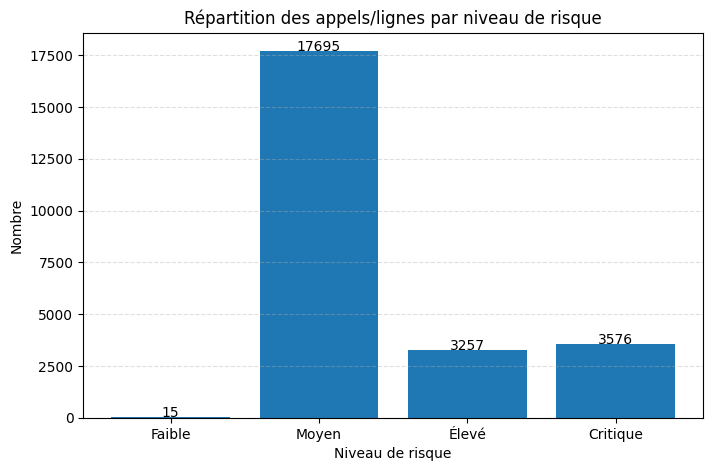

In [31]:
# ============================================================
# CELLULE 24 — VISUALISATION DES NIVEAUX DE RISQUE
# ============================================================

risk_counts = df_output["risk_level"].value_counts().reindex(
    ["Faible", "Moyen", "Élevé", "Critique"],
    fill_value=0
)

plt.figure(figsize=(8,5))
bars = plt.bar(risk_counts.index, risk_counts.values)

plt.title("Répartition des appels/lignes par niveau de risque")
plt.xlabel("Niveau de risque")
plt.ylabel("Nombre")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha="center")

plt.show()

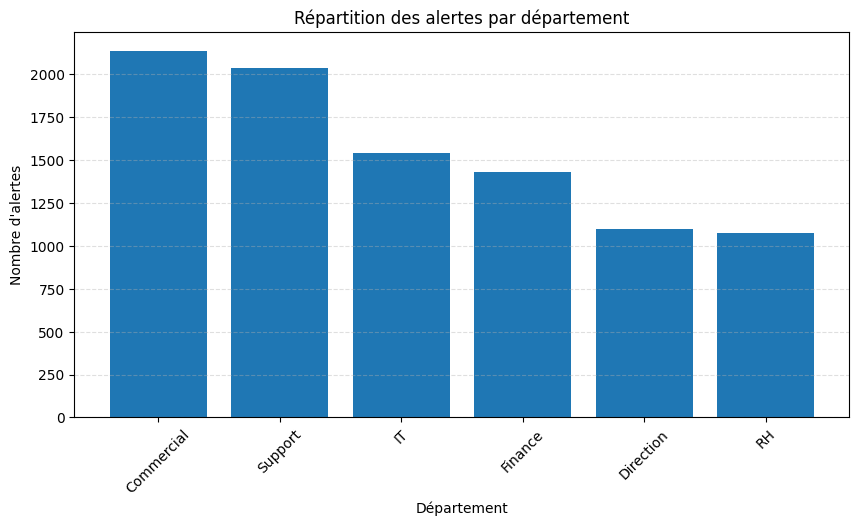

In [32]:
# ============================================================
# CELLULE 25 — ALERTES PAR DEPARTEMENT
# ============================================================

alert_dept = df_output[df_output["alert_flag"] == 1]["department"].value_counts()

plt.figure(figsize=(10,5))
plt.bar(alert_dept.index, alert_dept.values)
plt.title("Répartition des alertes par département")
plt.xlabel("Département")
plt.ylabel("Nombre d'alertes")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

In [33]:
# Recréation rapide de df_output si manquant
df_output = df_ma.copy()

if best_model_name == "Logistic Regression":
    full_proba = log_model.predict_proba(X_full_scaled)[:, 1]
elif best_model_name == "Random Forest":
    full_proba = rf_model.predict_proba(X)[:, 1]
else:
    full_proba = xgb_model.predict_proba(X)[:, 1]

df_output["fraud_risk_proba"] = full_proba
df_output["fraud_risk_score_100"] = (df_output["fraud_risk_proba"] * 100).round(1)

In [34]:
import os

output_filename = "/kaggle/working/telecom_cdr_fraud_output_maroc.csv"

df_output.to_csv(output_filename, sep=";", index=False)

print("✅ Output exporté :", output_filename)
print("✅ Modèle utilisé :", best_model_name)
print("📁 Fichiers :", os.listdir("/kaggle/working"))

✅ Output exporté : /kaggle/working/telecom_cdr_fraud_output_maroc.csv
✅ Modèle utilisé : XGBoost
📁 Fichiers : ['telecom_cdr_fraud_output_maroc.csv', '__notebook__.ipynb']


In [35]:
# ============================================================
# CELLULE 26 — EXPORT FINAL
# ============================================================

import os

output_filename = "/kaggle/working/telecom_cdr_fraud_output_maroc.csv"

df_output.to_csv(output_filename, sep=";", index=False)

print("✅ Output exporté :", output_filename)
print("✅ Modèle utilisé pour l'output final :", best_model_name)
print("📁 Fichiers :", os.listdir("/kaggle/working"))

✅ Output exporté : /kaggle/working/telecom_cdr_fraud_output_maroc.csv
✅ Modèle utilisé pour l'output final : XGBoost
📁 Fichiers : ['telecom_cdr_fraud_output_maroc.csv', '__notebook__.ipynb']


## 🧠 Conclusion — Détection de fraude Telecom (CDR)

Dans ce projet, nous avons développé une pipeline complète de détection de fraude à partir d’un dataset de type Telecom CDR (Call Detail Records), adaptée à un contexte métier inspiré du Maroc.

### 📊 Approche adoptée

L’analyse a suivi plusieurs étapes clés :

- Prétraitement et nettoyage des données
- Enrichissement du dataset avec des variables métier (coût en MAD, roaming, départements, opérateurs)
- Construction d’une **cible réelle de fraude** à partir de la variable `transaction_status`
- Feature engineering (notamment sur les variables temporelles)
- Entraînement et comparaison de plusieurs modèles de Machine Learning

### 🤖 Modèles évalués

Trois modèles ont été testés :

- Logistic Regression  
- Random Forest  
- XGBoost  

Les performances ont été évaluées à l’aide de métriques telles que le **ROC AUC**, l’accuracy et la validation croisée.

### 🏆 Résultats obtenus

Le modèle **XGBoost** s’est révélé être le plus performant, avec :

- ROC AUC ≈ **0.62**
- ROC AUC (cross-validation) ≈ **0.63**

Ces résultats indiquent que le modèle est capable de détecter certains comportements frauduleux, bien que le signal prédictif reste modéré.

### 📉 Limites du modèle

- Le dataset ne contient pas un grand nombre de variables fortement discriminantes
- Certaines variables importantes dans un contexte réel (historique client, comportement long terme, profils utilisateurs) sont absentes
- Les performances restent donc limitées en termes de précision globale

### 💡 Apports du projet

Malgré ces limites, ce projet permet de :

- Mettre en place une **pipeline ML complète et cohérente**
- Exploiter une **cible réelle de fraude**
- Générer un **score de risque interprétable**
- Détecter des comportements suspects (roaming, appels internationaux, coûts élevés)
- Produire des **alertes et recommandations métier**
- Alimenter un **dashboard intelligent pour la gestion de flotte téléphonique**

### 🚀 Perspectives d’amélioration

- Enrichissement du dataset avec des données réelles supplémentaires
- Intégration de variables comportementales (historique d’usage, profil utilisateur)
- Utilisation de modèles plus avancés (Deep Learning, modèles séquentiels)
- Déploiement en temps réel dans une architecture SaaS

---

### 🎯 Conclusion générale

Ce projet constitue une base solide pour la mise en place d’un système intelligent de détection de fraude dans un contexte Telecom.  
Il démontre la capacité à transformer des données brutes en **insights exploitables**, et à concevoir une solution orientée **décision métier et optimisation des coûts**.